# Prosjekt 2 – Interacting Motor Proteins

## TMA4240 – Vitenskapelige bereginger 
**Navn:** Herman, Erik og Johannes  
**Dato:** 8 mars 2026  

---

Denne notebooken inneholder løsninger og analyser knyttet til oppgavene i Prosjekt 2.  
Vi bruker Python og numeriske metoder for å analysere systemet.

## Oppgave 1

### Oppgave 1a)

Vi starter med å skrive uttrykket i Eq. (6) på en mer enkel form for å gjøre det lettere for oss selv.
Definer den Gaussiske kjernen

$$
G(x,t)=\frac{1}{\sqrt{4\pi Dt}} e^{-x^2/4Dt}.
$$

Da kan løsningen vi skrive løsningen som

$$
\phi(x,t)=\int_{-\infty}^{\infty} h(y)\,G(x-y,t)\,dy.
$$

Dette er en konvolusjon mellom initialfordelingen $h(y)$ og med det man kan kalle en Gausisk kjerne $G$.

---

### Derivasjon og diffusjonslikningen

For å vise at $\phi(x,t)$ oppfyller diffusjonslikningen

$$
\frac{\partial \phi}{\partial t}
=
D\frac{\partial^2 \phi}{\partial x^2},
$$

må vi derivere med hensyn på $t$ og $x$.

Siden $G(x,t)$ er glatt for $t>0$, og både funksjonen og dens deriverte avtar raskt når $|x|\to\infty$, kan vi flytte derivasjonen inn i integralet. Da får vi

$$
\frac{\partial \phi}{\partial t}
=
\int h(y)\,\frac{\partial G}{\partial t}\,dy,
$$

og tilsvarende for romderiverte.

En direkte derivasjon av $G(x,t)$ gir

$$
\frac{\partial G}{\partial t}
=
G\left[
\frac{x^2}{4Dt^2}
-
\frac{1}{2t}
\right],
$$

og

$$
\frac{\partial^2 G}{\partial x^2}
=
G\left[
\frac{x^2}{4D^2t^2}
-
\frac{1}{2Dt}
\right].
$$

Ved å multiplisere den siste med $D$ ser vi at

$$
\frac{\partial G}{\partial t}
=
D\frac{\partial^2 G}{\partial x^2}.
$$

Siden integralet er lineært, følger det da at også $\phi(x,t)$ oppfyller diffusjonslikningen.

---

### Grensen når $t \to 0$

Når tiden går mot null, blir den Gaussiske kjernen stadig smalere og nærmer seg det vi hadde i 4k som er en Dirac-deltafunksjon:

$$
G(x,t)\to \delta(x).
$$

Dermed får vi

$$
\phi(x,0)
=
\int h(y)\delta(x-y)\,dy
=
h(x).
$$

Dette viser at $h(x)$ er initialbetingelsen.

---

### Fysisk tolkning av $h(y)$

Fysisk kan $h(y)$ tolkes som fordelingen av partikler (eller masse, eller sannsynlighet) ved starttidspunktet $t=0$.

Hver liten del av initialfordelingen rundt et punkt $y$ kan betraktes som en liten "kilde" som sprer seg i rommet på grunn av diffusjon. Spredningen fra en slik startposisjon beskrives av den Gaussiske fordelingen $G(x-y,t)$.

Den totale løsningen $\phi(x,t)$ får vi ved å summere alle disse bidragene. Dette betyr at

- $h(y)$ forteller hvor mye materiale som opprinnelig befant seg i punktet $y$.
- $G(x-y,t)$ beskriver hvordan dette materialet sprer seg over tid.
- Integralformelen legger sammen bidragene fra alle mulige startpunkter.

Vi tror også man kan se dette fra et sannsynlighetsteoretisk perspektiv. Hvis vi følger én tilfeldig partikkel, kan $h(y)$ tolkes som sannsynligheten for at den startet i $y$, mens $G(x-y,t)$ er sannsynligheten for at den befinner seg i $x$ ved tidspunktet $t$, gitt at den startet i $y$. Løsningen kan dermed forstås som et uttrykk for total sannsynlighet.

Med andre ord kan vi tenke på $h(y)$ som et slags "startbilde" av systemet, mens diffusjonslikningen beskriver hvordan dette bildet gradvis jevnes ut etter hvert som tiden går.



### Oppgave 1b)

Vi er gitt Boltzmann-fordelingen
$$
P(x)=\frac{e^{-\beta V(x)}}{Z}.
$$

Vi antar at overgangssannsynligheten i random walk-en er proporsjonal med $P(x)$. 
Dersom partikkelen står i $x_0$, finnes det derfor en konstant $C$ slik at
$$
p^+ = C P(x_0+1), \qquad
p^0 = C P(x_0), \qquad
p^- = C P(x_0-1).
$$

Siden dette er de eneste tre mulighetene i ett steg, må
$$
p^+ + p^0 + p^- = 1.
$$

Setter vi inn uttrykkene over, får vi
$$
C \big[ P(x_0-1) + P(x_0) + P(x_0+1) \big] = 1,
$$
og dermed
$$
C =
\frac{1}{P(x_0-1)+P(x_0)+P(x_0+1)}.
$$

Setter vi dette tilbake i uttrykket for $p^+$, får vi
$$
p^+ =
\frac{P(x_0+1)}
{P(x_0-1)+P(x_0)+P(x_0+1)}.
$$

Setter vi inn Boltzmann-fordelingen $P(x)=e^{-\beta V(x)}/Z$, får vi
$$
p^+ =
\frac{e^{-\beta V(x_0+1)}/Z}
{
e^{-\beta V(x_0-1)}/Z
+
e^{-\beta V(x_0)}/Z
+
e^{-\beta V(x_0+1)}/Z
}.
$$

Faktoren $Z$ kanselleres i teller og nevner, slik at
$$
p^+ =
\frac{e^{-\beta V(x_0+1)}}
{
e^{-\beta V(x_0-1)}
+
e^{-\beta V(x_0)}
+
e^{-\beta V(x_0+1)}
}.
$$

Ved å dele teller og nevner på $e^{-\beta V(x_0+1)}$, får vi
$$
p^+ =
\frac{1}
{
1
+
e^{-\beta [V(x_0-1)-V(x_0+1)]}
+
e^{-\beta [V(x_0)-V(x_0+1)]}
}.
$$

Tilsvarende fremgangsmåte gir uttrykkene for $p^0$ og $p^-$.

### Oppgave 1c) 

Vi ser på hvordan overgangssannsynlighetene oppfører seg når temperaturen enten er svært høy eller svært lav. Siden

$$
\beta = \frac{1}{k_B T},
$$

er det forholdet mellom den termiske energien $k_B T$ og potensialforskjellene $|V(x+1)-V(x)|$ som bestemmer hvordan dynamikken i systemet blir.

### Høy temperatur: $k_B T \gg |V(x+1)-V(x)|$

Når temperaturen er høy, er den termiske energien mye større enn forskjellene i potensialet. Dette innebærer at

$$
\beta \ll 1,
$$

og dermed blir produktene $\beta \Delta V$ små.

I denne situasjonen kan eksponentialene i overgangssannsynlighetene tilnærmes med

$$
e^{-\beta \Delta V} \approx 1.
$$

Når eksponentialleddene blir omtrent like store, mister potensialet i praksis betydning. De tre mulige utfallene – å gå til høyre, til venstre eller å bli stående – får derfor omtrent samme sannsynlighet. Vi får dermed

$$
p^+ \approx p^0 \approx p^- \approx \frac{1}{3}.
$$

**Tolkning:** Ved høy temperatur er det de termiske fluktuasjonene som dominerer. Partikkelen påvirkes lite av små forskjeller i potensialet og beveger seg derfor nesten tilfeldig. Random walk-en blir dermed tilnærmet symmetrisk.

---

### Lav temperatur: $k_B T \ll |V(x+1)-V(x)|$

Vi kan også se på den motsatte grensen, der temperaturen er lav. Da er den termiske energien mye mindre enn potensialforskjellene, og vi får

$$
\beta \gg 1.
$$

I dette tilfellet blir eksponentialleddene svært følsomme for energiforskjellene. Dersom en av naboposisjonene har lavere potensialenergi enn de andre, vil eksponentialleddet for denne retningen dominere i nevneren til overgangssannsynligheten.

Dette gjør at sannsynligheten for å bevege seg mot lavere energi nærmer seg 1, mens de andre sannsynlighetene går mot 0.

**Tolkning:** Ved lav temperatur blir bevegelsen i praksis nesten deterministisk. Partikkelen vil da som regel bevege seg mot lavere potensial, altså «rulle nedover» i energilandskapet. De termiske fluktuasjonene er nå for svake til å føre partikkelen over energibarrierer.

---

### Energiskala-argument

Det avgjørende i denne oppgaven er at vi skal sammenligne størrelsen på de energiskalaene vi tenker er riktige å ta med.

- Når $k_B T$ er mye større enn potensialforskjellene, kan potensialet i stor grad neglisjeres, og systemet oppfører seg omtrent som en symmetrisk tilfeldig vandring.
- Når $k_B T$ derimot er mye mindre enn potensialforskjellene, er det potensialet som styrer dynamikken, og systemet drives mot tilstander med lavere energi.

Dette viser hvordan en enkel sammenligning av energiskalaer kan gjøre det lettere å forstå hvilken fysisk effekt som dominerer i de ulike temperaturgrensene.

## Oppgave 2

Denne delen består av tre deler:

- **2a:** Partikkelfordeling uten frastøtning
- **2b:** Partikkelfordeling med frastøtning
- **2c:** Effekt av lav temperatur \($\beta k$ = 1 vs $\beta k$ = 1000\)

In [9]:
#INITIALISERING

#importering
import numpy as np
from matplotlib import pyplot as plt

#konstanter
params_oppave_2 = {
"beta_k"                : 1,
"antallPartikler"       : 101,
"antallSimulasjoner"    : 100,
"timeSteps"             : 200
}

In [10]:
#HJELPEFUNKSJONER

def lag_prob_tabeller(params):
    beta_k = params["beta_k"]

    #siden potensialfunksjonene er så simple finner vi at p_pos og p_neg er konstante for både V1 og V2 (altså uavhengig av x)
    prob_tabell_V_i = {
    "p_pos" : 1/3,
    "p_neg" : 1/3
    }

    prob_tabell_V_ii = {
    "p_pos" : 1/(1 + np.exp(-2*beta_k) + np.exp(-beta_k)),
    "p_neg" : np.exp(-2*beta_k) / (                          #må skrives slik for å ikke få overflow
        np.exp(-2*beta_k) + 1 + np.exp(-beta_k)
    )
    }
    return prob_tabell_V_i, prob_tabell_V_ii

In [11]:
#SIMULERINGSFUNKSJONER

#Oppgave 2a simulering
def particleWalk_uten_Repulsion_sim(prob_tabell, params):                           #kan være forskjellig potensialfunksjon
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg:
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                partiklerPos[i] += 1

    return partiklerPos

#Oppgave 2b simulering
def particleWalk_med_Repulsion_sim(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)

    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg:
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos

In [12]:
#OPPGAVEFUNKSJONER

#Oppgave 2a
def oppgave_2a(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_uten_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist


#Oppgave 2b
def oppgave_2b(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]
    

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)         
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_med_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist

In [13]:
#Plottefunksjoner

#oppgave 2a og 2b
def plot_oppgave_2_a_b(oppgave, params, tittel):
    prob_tabell_V_i, prob_tabell_V_ii = lag_prob_tabeller(params)
    x_aksen_i, averageDist_i = oppgave(prob_tabell_V_i, params)
    x_aksen_ii, averageDist_ii = oppgave(prob_tabell_V_ii, params)

    plt.figure(figsize=(8,5))

    plt.plot(x_aksen_i, averageDist_i, label="$V(x)=k$")
    plt.plot(x_aksen_ii, averageDist_ii, label="$V(x)=-kx$")

    plt.xlabel("posisjon i $x$-retning")
    plt.ylabel("gjennomsnittlig antall partikler")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.title(tittel)

    plt.show()

#oppgave 2c
def plot_2c(params, beta_k_lowT=1000):

    params_lowT = params.copy()
    params_lowT["beta_k"] = beta_k_lowT

    _, V_ii = lag_prob_tabeller(params)
    _, V_ii_lowT = lag_prob_tabeller(params_lowT)

    x_a1, y_a1 = oppgave_2a(V_ii, params)
    x_a2, y_a2 = oppgave_2a(V_ii_lowT, params_lowT)

    x_b1, y_b1 = oppgave_2b(V_ii, params)
    x_b2, y_b2 = oppgave_2b(V_ii_lowT, params_lowT)

    fig, ax = plt.subplots(1,2, figsize=(12,4))


    ax[0].plot(x_a1, y_a1, color="C0", label=r"$\beta k=1$")
    ax[0].plot(x_a2, y_a2, color="C1", label=rf"$\beta k={beta_k_lowT}$")
    ax[0].set_title("2a(ii): V(x)=-kx")

    ax[1].bar(x_b1, y_b1, width=1, color="C0", alpha=0.6, label=r"$\beta k=1$")
    ax[1].bar(x_b2, y_b2, width=1, color="C1", alpha=0.6, label=rf"$\beta k={beta_k_lowT}$")
    ax[1].set_title("2b(ii): V(x)=-kx")

    for a in ax:
        a.set_xlabel("posisjon x")
        a.set_ylabel("gjennomsnittlig antall partikler")
        a.grid(alpha=0.3)
        a.legend()
        a.set_xlim(0,300)

    plt.tight_layout()
    plt.show()

### Oppgave 2a)

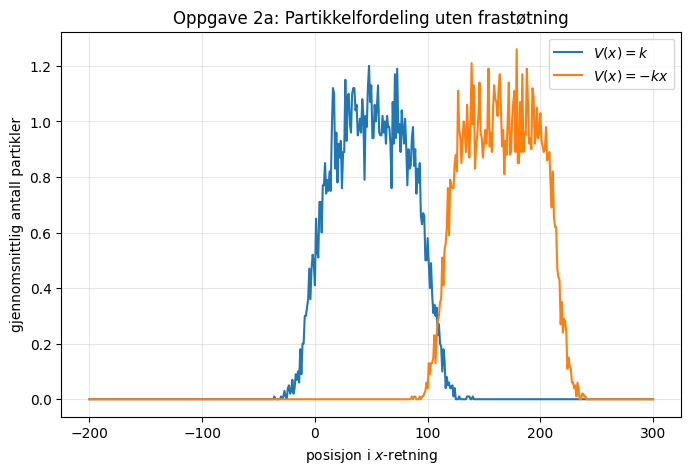

In [14]:
plot_oppgave_2_a_b(oppgave_2a, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling uten frastøtning")

Figuren viser hvordan partikler uten frastøtning er gjennomsnittlig fordelt etter $100$ simulasjoner. 

For potensial $V(x)=k$ er grafen sentrert rundt omtrent $x = 50$, og ser symmetrisk ut rundt dette punktet som gir mening da bevegelsen til hver partikkel er symmetisk i snitt. Ved $x = 50$ er snittet rundt $1.0$ partikler, men det er store variasjoner her for hver $x$-posisjon grunnet støy. Man ser også at grafen har en ganske bratt hale som går utover sidene til startposisjonen ved $x = 0$ og $x = 100$, som er forventet da partiklene vil bre seg utover. Ved $V(x) = k$ er $p_{\text{neg}} = p_{0} = p_{\text{pos}} = \frac{1}{3}$, noe som gjør at partiklene er like sannsynlig å gjøre alle muligheter. Dette ser man ganske godt i grafen ved at gjennomsnittsposisjonen er omtrent lik startposisjonen.

For potensial $V(x) = -kx$ ser man at grafen ligner på $V(x) = k$, men at den er forskjøvet slik at midtpunktet ligger rundt $x = 160$. Man forventer også dette her ettersom man for $\beta k = 1$ får omtrent følgende sannsynligheter: $p_{\text{neg}}  = 0.09$, $p_{0} = 0.24$, $p_{\text{pos}} = 0.67$. Altså flytter partiklene seg i snitt mot høyre, noe som samsvarer godt med det vi observerer i grafen. Dersom man gjør litt enkel matte vil man kunne regne ut at $E[S] = (-1)\cdot 0.09 + 0\cdot 0.24 + 1\cdot 0.67 = 0.58$, hvor $S$ er et steg, noe som gir at med $\text{timeSteps} = 200$ steg vil forventet antall steg totalt vil bli $0.58 \cdot 200 = 116$ steg. Så for partikkel som starter i x= 50 er forventet sluttposisjon x=166. Dette samsvarer ganske godt med hvor midtpunktet blir observert å ligge.

### Oppgave 2b)

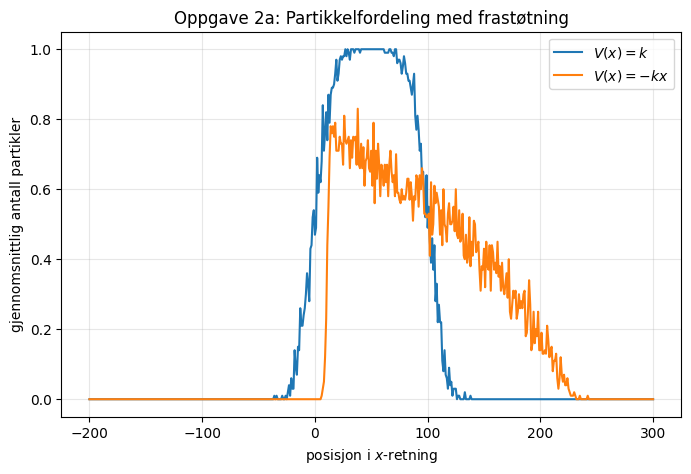

In [15]:
plot_oppgave_2_a_b(oppgave_2b, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling med frastøtning")

Figuren viser hvordan partikler med frastøtning er gjennomsnittlig fordelt etter $100$ simulasjoner.

For potensial $V(x)=k$ er grafen fortsatt sentrert rundt $x = 50$ og tilnærmet symmetrisk. Rundt midtpunktet ser man at gjennomsnittet ligger helt flatt ved $1.0$ partikkel i gjennomsnitt. Dette tyder på at partiklene som ligger lengst unna ytterkantene av startkonfigurasjonen ikke får muligheten til å bevege seg etter kun $200$ timeSteps. Dette gir mening da de må vente til nabopartikkelen har flyttet seg, som igjen må vente til deres nabopartikkel har flyttet seg osv. Med for få timeSteps forventer man dermed at partikler i midten forblir uendret. Det er også et godt tegn at grafen ikke krysser over $1.0$ partikler i gjennomsnitt, da dette ville ha betydd at vi hadde hatt en feil i koden.

For potensial $V(x)= -kx$ ser grafen ut til å ha en tilnærmet lineær nedgang i gjennomsnittlig partikkelantall som x øker. Som man ser er det ingen partikler etter $200$ timeSteps som beveger seg forbi venstre startpunkt ved $x = 0$. Dette gir mening da sannsynligheten for at partikkelen lengst til venstre vil krysse dette punktet er svært liten ettersom $p_{\text{neg}} = 0.09$ og det krever at partikkelen tar flere steg til venstre enn høyre. Ved venstre side at grafen ser man også at snittet ligger på rundt $0.8$ partikler. Dette tyder på at patiklene lengst til venstre ikke får beveget seg så mye, som gir mening da de må vente til at alle partikler til høyre for seg har flyttet seg ettersom vi har frastøtning. Partikler som starter på høyre side vil ha flere muligheter til å flytte seg og flytte seg lenger, som er hvorfor gjennomsnittlig partikkeltetthet er lavere på høyre side. Man kan også observere at arealet under grafen er omtrent lik som i startposisjonen, som tyder på at masse er bevart og at simuleringen er riktig.

### Oppgave 2c)

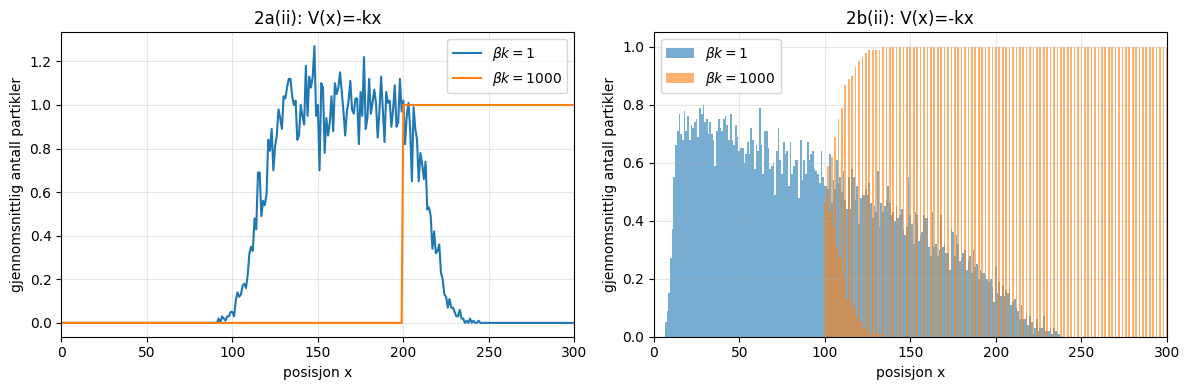

In [16]:
plot_2c(params_oppave_2)

Her har vi valgt å ikke plotte 2a(i) og 2b(i) ettersom de ikke avhenger av $\beta k$ og dermed vil plottet bli det samme som tidligere.

I figuren over har vi plottet 2a(ii) og 2b(ii) med $\beta k = 1$ og $\beta k = 1000$ for å sammenligne hvordan $\beta k$ påvirker den gjennomsnittlige partikkelfordelingen.

For 2a(ii) med $\beta k = 1000$ ser man at alle partiklene har beveget seg til høyre. Grunnen til dette er at ved $\beta k = 1000$ og $V(x) = -kx$ er $p_{\text{neg}} \approx 0$, $p_{0} \approx 0$ og $p_{\text{pos}} \approx 1$, slik at alle partiklene tilnærmet garantert beveger seg mot høyre dersom de har muligheten. Så etter $\text{timeSteps} = 200$ runder har alle partikler flyttet seg $200$ steg fra sin opprinnelige startposisjon som stemmer overens med at grafen ser ut til å gå til 1.0 ved x = 200. En sentral ting som gjør at dette skjer er at partiklene ikke påvirker hverandre, så alle partikler kan flytte seg uten å bli blokkert av noen andre. 

For 2b(ii) med $\beta k = 1000$ har også alle partikler flyttet seg til høyre, men her ser man at grafen starter på x = 100 og går bort til x = 300. Det man også observerer her er at det oppstår tomme posisjoner mellom toppene. En interessant ting man og kan se her er at fra omtrent rundt $x = 125$ havner partiklene ofte i samme posisjon i hver simulering, så når man tar gjennomsnittet får man disse piggene i posisjoner hvor partikler stopper, og tomrom mellom dem. Systemet blir dermed nesten deterministisk, og hvis $timeSteps$ hadde vært større ville vi ha bare sett disse piggene. 

Det er en matematisk grunn til hvorfor vi får dette resultatet. Vi velger å analysere dette litt nærmere da det er meget interessant. For å gjøre dette velger vi å nummerere partiklene fra høyre til venstre med partikkel 1 helt til høyre, partikkel 2 nest til høyre osv til partikkel 101 helt til venstre. Vi skal også her gjøre en antakelse om at $p_{\text{pos}} = 1$. La oss først se på partikkel 1, den vil dermed ta 200 steg mot høyre. Partikkel 2 vil også "kunne" ta 200 steg, men det krever at partikkel 1 alltid plukkes før partikkel 2 i rekkefølgen de skal flyttes i, noe som er svært usannsynlig ($\left(\frac{1}{2}\right)^{200}$). Så hvis man antar at partikkel 2 minst en gang plukkes før partikkel 1, vil det etter den flytterunden bli et mellomrom mellom dem. Etter dette vil dette mellomrommet forbli gjennom resten av simuleringen ettersom partikkel 2 dermed alltid vil ha muligheten til å flytte høyre. Dette resulterer i at partikkel 2 får garantert minst 199 steg totalt i en simulering, altså mister partikkel 2 maks ett steg. Vi antar så en worst case og sier at partikkel 2 får 199 steg i en simulering. Dermed kan vi bruke samme logikken mellom partikkel 2 og partikkel 3. Ettersom vi er i worst case kan vi dermed si at partikkel 3 kun får 199 runder til å flytte seg, og at partikkel 2 flytter seg garantert i hver slik runde. Ved samme logikk som istad vil dermed partikkel 3 få minst 198 steg og maks miste 2 steg. Rekursivt kan man fortsette slik ned til partikkel 101 som dermed vil få garantert minst 100 steg. Alternativt kan man også komme fram til samme konklusjon ved å si at i worst-case så flyttes partiklene alltid fra venstre til høyre, som også gir minst 100 steg for partikkel 101. Dette samsvarer godt med det vi observerer i grafen. Man kan også legge merke til at fra $x = 100$ til rundt $x = 125$ har grafen ikke samme tomrom som man observerer fra rundt $x = 125$ og utover. Grunnen til dette er fordi antakelsen om at eksempelvis partikkel 101 bare kan flytte seg i runder når partikkel 100 kan flytte seg, blir for enkel. Det som i praksis kan skje her er at partikkel 101 kan "ta igjen" partikkel 100 og tette tomrommet mellom dem (partikkel 101 får tilnærmet $99$ muligheter til å bli nabo med partikkel 100 igjen dersom de ikke allerede er det ettersom partikkel 100 kan miste maks $99$ steg). Hvis dermed partikkel 100 blir valgt før 101 i siste runde vil de ende opp som naboer. Så i de tilfeller partiklene ender opp som naboer etter en simulering, gir det et bidrag på gjennomsnittlig antall partikler i hver posisjon og "tetter" igjen mellomrommene i plottet.

## Oppgave 3)

In [17]:
#INITIALISERING

#Importering
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import erfc
import pandas as pd
from IPython.display import display

#konstanter
params_oppgave_3 = {
    "alfa"      : 0.8,
    "Tp"        : 500,
    "Nx"        : 100,
    "beta_k"    : 1000   
}
params_oppgave_3["L"] = 2*params_oppgave_3["Nx"]
params_oppgave_3["Np"] = 12*params_oppgave_3["Nx"]
params_oppgave_3["timeSteps"] = 20*params_oppgave_3["Tp"]

In [18]:
#HJELPEFUNKSJONER

#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (Nx-periode)/((1-alfa)*Nx)

def V2(x, params):                       
    return 0                       


#Sannsynlighetsfunksjoner p+ og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1)%L,params)-V((x+1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x+1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner

def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x+1)%L,params)-V((x-1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x-1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


#Look-up tabeller for raskere kjøring
def lookUpTabell_V1(params):
    L = params["L"]

    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V1, params)
        tabell_V1_p_neg[x] = p_neg(x, V1, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]

    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#oppgave 3a hjelpefunksjoner
def syklusSnitt(current, params):
    syklus_len = 2*params["Tp"]
    n_cycles = len(current)//syklus_len
    return np.arange(1, n_cycles+1), np.array([current[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

def init_partikler_3a(params):
    L = params["L"]
    return np.repeat(np.arange(0,L), 6)


#oppgave 3b hjelpefunksjoner
def init_partikler_3b(params):
    Nx = params["Nx"]
    Np = params["Np"]
    return np.repeat([0,Nx], Np//2)


#oppgave 3c hjelpefunksjoner
def init_partikler_3c(params):
    Np = params["Np"]
    return np.zeros(Np, dtype=int)

In [19]:
#SIMULERINGSFUNKSJONER

#oppgave 3 generelt
def particleCurrent_sim(partiklerPos, params, tabeller):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    startPot_pos_table = tabeller["startPot_pos_table"]
    startPot_neg_table = tabeller["startPot_neg_table"]
    secondPot_pos_table = tabeller["secondPot_pos_table"]
    secondPot_neg_table = tabeller["secondPot_neg_table"]

    particleCurrent = np.zeros(timeSteps)

    for k in range(timeSteps):
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = startPot_pos_table, startPot_neg_table
        else:
            tabell_p_pos, tabell_p_neg = secondPot_pos_table, secondPot_neg_table
        
        randomtabell = np.random.rand(Np)

        posProb = tabell_p_pos[partiklerPos]
        negProb = tabell_p_neg[partiklerPos]

        neg_flytt = (randomtabell <= negProb)
        pos_flytt = (~neg_flytt) & (randomtabell >= (1 - posProb))

        partiklerPos[neg_flytt] -= 1
        partiklerPos[pos_flytt] += 1
        partiklerPos %= L

        n_pos = pos_flytt.sum()
        n_neg = neg_flytt.sum()
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

In [20]:
#OPPGAVEFUNKSJONER

#oppgave 3a
def oppgave_3a(params):
    lokal_params = params.copy()
    partiklerPos = init_partikler_3a(params = lokal_params)

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3a = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3a)
    
    particleCurrent_syklusSnitt = syklusSnitt(particleCurrent, params = lokal_params)

    return particleCurrent_syklusSnitt


#oppgave 3b
def oppgave_3b(params):
    lokal_params = params.copy()
    lokal_params["Np"] = 40*lokal_params["Nx"]

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3b = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(1, 1001, 50)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3b)

        resultatarray[i] = particleCurrent.mean()

    return Tp_array, resultatarray


#oppgave 3c
def oppgave_3c(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    resultatarray = np.zeros(len(alfa_array))

    for i in range(len(alfa_array)):
        lokal_params["alfa"] = alfa_array[i]
        partiklerPos = init_partikler_3c(params = lokal_params)

        tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
        tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

        tabeller_potensial_3c = {
            "startPot_pos_table" : tabell_V2_p_pos,
            "startPot_neg_table" : tabell_V2_p_neg,
            "secondPot_pos_table": tabell_V1_p_pos,
            "secondPot_neg_table": tabell_V1_p_neg
        }
        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3c)
        resultatarray[i] = particleCurrent.mean()
    
    Tp = lokal_params["Tp"]
    Nx = lokal_params["Nx"]

    analytisk_3c_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))

    return alfa_array, resultatarray, analytisk_3c_array


#oppgave 3d
def oppgave_3d(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])
    resultatarray = np.zeros((len(beta_k_array), len(alfa_array)))

    for k in range(len(beta_k_array)):
        lokal_params["beta_k"] = beta_k_array[k]
        mdltr_resultatarray = np.zeros(len(alfa_array))

        for i in range(len(alfa_array)):
            lokal_params["alfa"] = alfa_array[i]
            partiklerPos = init_partikler_3c(params = lokal_params)

            tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
            tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

            tabeller_potensial_3d = {
                "startPot_pos_table" : tabell_V2_p_pos,
                "startPot_neg_table" : tabell_V2_p_neg,
                "secondPot_pos_table": tabell_V1_p_pos,
                "secondPot_neg_table": tabell_V1_p_neg
            }
            particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3d)
            mdltr_resultatarray[i] = particleCurrent.mean()
        resultatarray[k, :] = mdltr_resultatarray

    Nx = lokal_params["Nx"]
    Tp = lokal_params["Tp"]

    analytisk_3d_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))
    
    return alfa_array, resultatarray, analytisk_3d_array


#oppgave 3e
def oppgave_3e(params):
    lokal_params = params.copy()
    lokal_params["Nx"] = 10
    lokal_params["Np"] = 40*lokal_params["Nx"]
    lokal_params["alfa"] = 0.8

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3e = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(80, 1500, 20)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3e)

        resultatarray[i] = particleCurrent.mean()
    
    Nx = lokal_params["Nx"]
    alfa = lokal_params["alfa"]

    analytisk_3e_array = (Nx/(4*Tp_array))*(erfc((alfa*Nx/2)*np.sqrt(3/Tp_array)) - erfc(((1-alfa)*Nx/2)*np.sqrt(3/Tp_array)))

    return Tp_array, resultatarray, analytisk_3e_array

In [21]:
#PLOTTEFUNKSJONER

#oppgave 3a
def plot_oppgave_3a(params, alfa=None):
    lokal_params = params.copy()

    if alfa is not None:
        lokal_params["alfa"] = alfa

    syklus_array, particleCurrent_3a = oppgave_3a(lokal_params)

    plt.figure(figsize=(8,4))
    plt.plot(syklus_array, particleCurrent_3a, marker="o", markersize=4)
    plt.axhline(0, color="black", linewidth=1, alpha=0.4)
    plt.xlim(1, syklus_array[-1])

    plt.xlabel(r"syklusnummer")
    plt.ylabel(r"$J_{avg}$ per syklus")
    plt.title(r"Oppgave 3a: gjennomsnittlig partikkelstrøm som funksjon av syklus")
    plt.grid(alpha=0.3)

    plt.show()
    df = pd.DataFrame({"syklus n": syklus_array, "J_avg(n)": particleCurrent_3a})
    display(df)


#oppgave 3b
def plot_oppgave_3b(params):
    Tp_array, particleCurrent_3b = oppgave_3b(params)
    
    plt.figure(figsize=(8,4))
    plt.plot(Tp_array, particleCurrent_3b)

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{avg}$")
    plt.title(r"Oppgave 3b: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#oppgave 3c
def plot_oppgave_3c(params):
    alfa_array, particleCurrent_3c, analytisk_3c_array = oppgave_3c(params)

    plt.figure(figsize=(8,4))
    plt.plot(alfa_array, particleCurrent_3c, label="simulering")
    plt.plot(alfa_array, analytisk_3c_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3c: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show() 


#oppgave 3d
def plot_oppgave_3d(params):
    alfa_array, particleCurrent_3d, analytisk_3d_array = oppgave_3d(params)

    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])

    plt.figure(figsize=(10,5))

    for beta_k, current in zip(beta_k_array, particleCurrent_3d):
        plt.plot(alfa_array, current, label=rf"$\beta k = {beta_k}$")

    plt.plot(alfa_array, analytisk_3d_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3d: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.grid(alpha=0.3)

    handles, labels = plt.gca().get_legend_handles_labels()

    plt.legend(handles[::-1], labels[::-1],
               bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


# oppgave 3e
def plot_oppgave_3e(params):
    Tp_array, particleCurrent_3e, analytisk_3e_array = oppgave_3e(params)

    plt.figure(figsize=(8,4))

    plt.plot(Tp_array, particleCurrent_3e, label="simulering")
    plt.plot(Tp_array, analytisk_3e_array, "--", color="gray", label="analytisk")

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3e: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### Oppgave 3a)

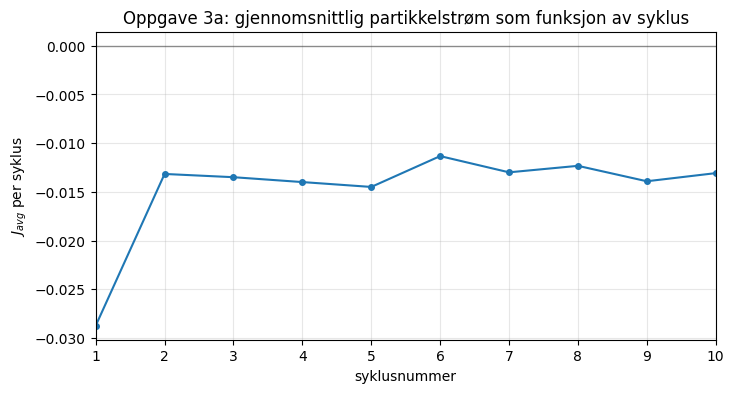

,syklus n,J_avg(n)
0,1,-0.028750
1,2,-0.013167
2,3,-0.013500
3,4,-0.014000
4,5,-0.014500
5,6,-0.011333
6,7,-0.013000
7,8,-0.012333
8,9,-0.013917
9,10,-0.013083


In [22]:
plot_oppgave_3a(params_oppgave_3)

#### 3a, $\alpha = 0.8$)

#### Hvorfor får vi non-zero strømning?

Som man kan observere i grafen og tabellen over ligger alle $J_{\text{avg}}$ verdier under -0.010. Årsaken til dette ligger i at man tar gjennomsnittet av partikkelstrømmen over en periode $2T_p$ hvor første halvperiode $T_p$ har potensialet $V_2(x) = k$ og den andre halvperioden

$$
V_1(x)=
\begin{cases}
\dfrac{kx}{\alpha N_x}, & 0 < x \le \alpha N_x \\
-\dfrac{kx}{(1-\alpha)N_x}, & -(1-\alpha)N_x < x \le 0
\end{cases}
$$

som er den periodiske funksjonen. Hvis man kun hadde tatt gjennomsnittet under $V_2$ potensialet ville man forvente å få i snitt en $J_{\text{avg}} = 0$ ettersom dette potensialet gir at $p_{\text{neg}} = p_{0} = p_{\text{pos}} = \frac{1}{3}$, noe som gir tilfeldig virrevandring uten strøm i en spesiell retning. Under halvperioden med $V_2$ blir derimot ikke sannsynlighetene like, men $p_{\text{neg}}$ størst. En intuitiv forklaring på hvorfor det blir slik kan man få av å tenke over hvordan potensialfunksjonen $V_1$ ser ut. En heuristisk regel, som vi skal prøve å underbygge litt mere snart, er at hvis en partikkel er i et potensialfelt vil den mest sannsynlig bevege seg i den retningen som tilsvarer at potensialet faller. Med $\alpha = 0.8$ blir dermed områder som modulo tilsvarer $(0, 0.8N_x]$, en positiv helning, som ettersom partikler beveger seg ned potensialet fører til at de går mot venstre. Samtidig tilsvarer områder som modulo tilsvarer $(0.8N_x, N_x]$ en negativ helning som fører til at partikler beveger seg mot høyre (mest sannsynlig). Ettersom området med positiv helning er større en området med negativ helning forventer man dermed i snitt en negativ strømning under potensialet $V_1$. Hvis man tenker seg at partiklene er tilfeldig plassert forventer man dermed at omtrent $80\%$ av partiklene beveger seg mot venstre mens $20\%$ beveger seg til høyre, noe som i snitt gir at rundt $60\%$ av partikler beveger seg mot venstre.

Grunnen til at vi kan bruke dette heuristiske argumentet om at partikler beveger seg nedover potensialet kommer fra hvordan sannsynlighetene regnes ut. I uttrykket for $p_{\text{pos}}$ opptrer det ledd i nevneren som inneholder eksponentialer av potensialforskjeller på formen $e^{-\beta (V(x_{\text{venstre}})-V(x_{\text{høyre}}))}$. I områder der potensialet har positiv helning vil $V(x_{\text{høyre}}) > V(x_{\text{venstre}})$. Dermed blir forskjellen $V(x_{\text{venstre}})-V(x_{\text{høyre}})$ negativ. 
Når dette multipliseres med $-\beta k = 1000$ (trakk ut k fra V(x) her) blir eksponenten positiv og stor, slik at eksponentialleddet blir svært stort. 
Siden dette står i nevneren i uttrykket for $p_{\text{pos}}$, fører det til at $p_{\text{pos}}$ blir svært liten. Sannsynligheten $p_0$ inneholder også et slikt eksponentialledd i nevneren. Dermed blir også $p_0$ liten i områder med positiv stigning, men den vil fortsatt være større enn $p_{\text{pos}}$. For $p_{\text{neg}}$ opptrer potensialforskjellen derimot med motsatt fortegn, slik at eksponenten blir negativ. Eksponentialleddet blir da svært lite, noe som gjør at bidraget til nevneren blir lite og sannsynligheten $p_{\text{neg}}$ derfor blir størst i områder der potensialet har positiv helning. Tilsvarende får man motsatt situasjon i områder der potensialet har negativ helning, hvor $p_{\text{pos}}$ blir den største sannsynligheten. Dette stemmer også med den fysiske intuisjonen om at partiklene foretrekker å bevege seg nedover i potensialet.

#### Sammenligning mellom $J_{\text{avg}}(0)$ og $J_{\text{avg}}(n)$, ($n > 0$)

Som man ser i grafen over ligger $J_{\text{avg}}(0)$ omtrent rundt -0.03, mens $J_{\text{avg}}(n)$, ($n > 0$) ser ut til å stabilisere seg rundt omtrent -0.015 allerede ved $n = 1$. Det tyder dermed på at $|J_{\text{avg}}|$ er størst i begynnelsen av simulasjonen. Grunnen til dette kan være at i initialposisjonen så er alle partiklene jevnt fordelt overalt, og etter første halvperiode $T_p$ vil de dermed fortsatt være omtrent jevnt fordelt, bare med litt mere støy. Det betyr at når andre halvperiode nå begynner $[T_p, 2T_p)$ vil omtrent $80\%$ av partikler befinne seg i områder med positiv helning ettersom $80\%$ av intervallet har positiv helning, som vil føre til at de vil bidra til en negativ strøming. Ettersom en $N_x = 100$ og $T_p = 500$ vil partiklene under $V_1$ ha mer enn nok tid til å ta nok steg til å lokalisere seg rundt nullpunkt som er i punkter hvor $x \bmod N_x = 0$. Det vil si at de vil innstille seg en tilnærmet likevektsstilling før denne halvperioden er ferdig. Når neste halvperiode begynner $[2T_p, 3T_p)$ er vi tilbake til $V_2$ potensialet og får tilfeldig virrevandring. Etter denne halvperioden vil partiklene ha beveget seg litt utover, men siden vandringen var tilfeldig i alle retninger vil de fortsatt ha størst forventningsverdi til å være lokalisert der de sluttet sist, altså ved nullpunktene. Når da neste halvperiode begynner $[3T_p, 4T_p)$ vil det dermed i snitt være flere partikler lokalisert rundt nullpunktene, og ettersom partikler ved nullpunkter ikke beveger seg forventer vi dermed å få en lavere strømning, noe vi også observerer. Grunnen til at vi fortatt observerer negativ strømning her likevel er det at ettersom partiklene beveger seg i snitt like ofte til venstre som til høyre under $V_2$ vil det ha vært i snitt like mange partikler til venstre som til høyre etter halvperioden $[2T_p, 3T_p)$. Gitt at hvertfall noen av disse partiklene beveger seg en avstand lenger enn $0.2N_x$ fra nullpunktet under denne halvperioden, vil disse partiklene ha større sannsynlighet for å befinne seg i et område som tilsvarer positiv helning ettersom i avstander lenger enn $0.2N_x$ fra nullpunkter vil prosentandelen område med positiv helning øke, som dermed vil føre til negativ strømning.

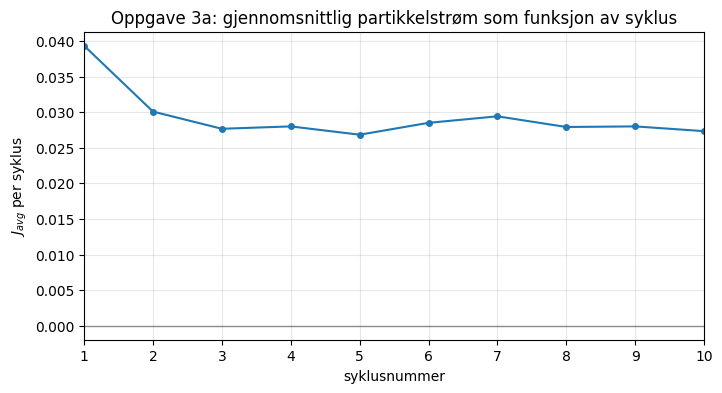

,syklus n,J_avg(n)
0,1,0.039333
1,2,0.030083
2,3,0.027667
3,4,0.028000
4,5,0.026833
5,6,0.028500
6,7,0.029417
7,8,0.027917
8,9,0.028000
9,10,0.027332


In [23]:
plot_oppgave_3a(params_oppgave_3, alfa = 0.1)

#### 3a, $\alpha = 0.1$)

For å unngå unødvendig gjentakelse gjør vi en kortere analyse for $\alpha = 0.1$, og fokuserer på forskjellene sammenlignet med resultatene for $\alpha = 0.8$. 

#### Hvorfor får vi non-zero strømning?

Situasjonen er lik som ved $\alpha = 0.8$ og vi får også non-zero strømnig her. Den eneste forskjellen her er at med $\alpha = 0.1$ vil potensialfunksjonen ha negativ helning i områder hvor $x \bmod N_x $ ligger i intervallet $(0.1N_x, N_x]$ Dette innebærer at nå vil $90\%$ av området partikler kan ligge i ha negativ helning på potensialfunksjonen, som vil føre til en positiv strøming mot høyre. Så likens som istad vil omtrent $90\%$ av partikler bevege seg mot høyre, mens $10\%$ mot venstre, som i snitt gir $80\%$ strøming mot høyre hvis partikler blir tilfeldig plassert på området.

#### Sammenligning mellom $J(0)$ og $J(n)$, ($n > 0$)

For $\alpha = 0.8$ var $J_{\text{avg}}(0) \approx -0.03$, mens for $\alpha = 0.1$ blir $J_{\text{avg}}(0) \approx 0.038$ Dette tyder på at absoluttverdien i strøming er strørre for $\alpha = 0.1$. Dette stemmer ganske godt med at det er en større prosentandel av området som har negativ helning, som dermed vil føre til at det blir mere strømning mot høyre. Man ser også i plottet for $\alpha = 0.1$ at det ser ut som at $J_{\text{avg}}(n)$ ser ut til å stabilisere seg rundt $0.028$. Dette er også større i absoluttverdi enn for $\alpha = 0.8$. Grunnen til dette kan være at nå må partiklene kun bevege seg en avstand på $0.1N_x$ fra nullpunktet før sannsynligheten for at de ligger på et område som tilsvarer strøming mot høyre er større enn sannsynligheten for å ligge på et område som tilsvarer strømning mot venstre. Dette vil da føre til at under halvperioder med $V_2$ vil tilfeldig virrevandring føre til at flere partikler vil befinne seg i høyregående områder enn ved $\alpha = 0.8$.

### Oppgave 3b)

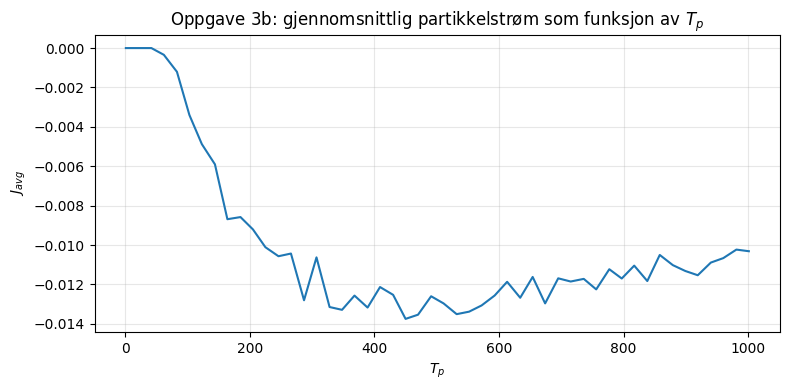

In [24]:
plot_oppgave_3b(params_oppgave_3)

Som man ser i grafen over er gjennomsnittlig partikkelstrøm ved lave verdier av $T_p \approx 0$. Deretter øker $|J_{\text{avg}}|$ som $T_p$ øker, og når et maximum rundt $T_p \approx 500$ før den igjen begynner å synke utover mot $T_p = 1000$. Grunnen til at $T_p \approx 0$ ved lave verdier av $T_p$ er mest sannsynlig fordi partiklene ikke får nok tid til å diffundere ut under $V_2$ potensial-halvperioden. Ettersom partiklene starter i nullpunktene vil de under $V_2$ bevege seg i snitt like mye til venstre som til høyre. Dersom $T_p$ er mindre enn $0.2Nx = 20$ vil ingen partikler ha nok steg til å bevege seg forbi fra en helning til neste helning til potensialfunksjon. Altså ingen partikler vil ha muligheten å gå fra et nullpunkt til nærmeste sted hvor potensialet går fra å ha positiv helning til å ha negativ helning, eller motsatt. Eksempelvis vil en partikkel i $x = N_x$ ha nærmeste ratchet-grense i $0.8Nx$, som er $20$ steg unna. Hvis partikkelen holder seg innenfor 20 steg fra nullpunktet vil dermed sannsynligheten for å havne i et område med positiv helning være lik sannsynligheten for å havne i et område med negativ helning. Det fører dermed til at partiklene i snitt vil bevege seg like mye mot høyre som venstre når $V_1$ potensial-halvperioden begynner.

Dersom derimot partiklene får nok tid til å ta nok steg, vil sannsynligheten for å havne i et område med negativ helning være større enn å havne i positiv helning (for $\alpha = 0.8$). Eksempelvis vil det være slik at hvis partiklene har nok steg til å flytte seg akkurat slik at de kan være innenfor en avstand på $0.8N_x$ vil sannsynligheten for å havne på et område med negativ helning være $\frac{0.8N_x + 0.6N_x}{1.6N_x} = 87.5\%$. Her har vi faktisk gjort en litt for grov forenkling å antatt at at partiklene blir uniformt fordelt under $V_2$ perioden, som ikke stemmer. Prisnippet er likevel det samme bare med en tilnærmet normalfordeling innenfor området. Det innebærer dermed at det finnes en maksimum verdi når sannsynligheten for å lande i et område som fører til venstre-vandring er størst.

Hvis partiklene får for mange steg derimot vil sannsynligheten for å havne på et område som fører til venste-vandring under $V_2$ gå mot $80\%$, ettersom det er andelen av område som har denne ratchet-potensialet. Det går dermed altså mot en tilnærmet uniform fordeling under $V_2$ halvperioden som vil føre til $|J_{\text{avg}}|$ vil minke sammenlignet med når den var middels stor.

### Oppgave 3c)

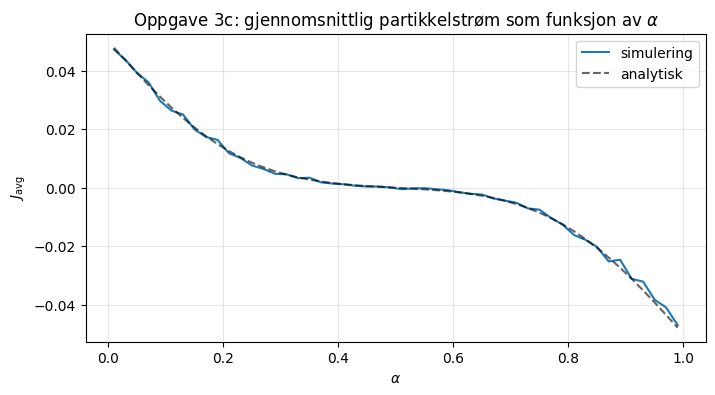

In [25]:
plot_oppgave_3c(params_oppgave_3)

I grafen over ser man enda bedre hvordan verdien av $\alpha$ påvirker gjennomsnittlig partikkelstrøm. Som man ser vil verdier av $\alpha$ under 0.5 føre til positive verdier av $J_{\text{avg}}$ gjennom at en større del av området partikler kan befinne seg i vil ha at potensialfunksjon har negativ helning. Motsatt vil verdier av $\alpha$ over 0.5 føre til negativ gjennomsnittlig partikelstrøm, da det blir en større del av området med positiv helning på potensialfunksjonen. Når $\alpha = 0.5$ vil potensialfunksjonen være symmetrisk rundt nullpunktene, noe som gir like mye strøming i hver retning, som forklarer hvorfor vi observerer $J_{\text{avg}} \approx 0$ her. Vi observerer også at grafen er antisymmetrisk rundt $\alpha = 0.5$. Dette betyr at $J_{\text{avg}}(\alpha) = -J_{\text{avg}}(1 - \alpha)$. Dette skyldes at ratchet-potensialet for ${(1 - \alpha)}$ er speilbildet av potensialet for ($\alpha$). Et intuitivt bilde man kan ha her er hvis man tenker på potensialfunksjonen som et landskap og partiklene som baller som ruller ned bakken. Jo større andel av bakker som går nedover mot venstre, jo mere negativ strøming får vi og motsatt hvis vi har en større andel bakker som går nedover mot høyre. Vi observerer også i grafen at simuleringen samsvarer ganske godt med den analytiske løsningen for gjennomsnittlig partikkelstrøming her. Årsaken til dette ligger i at $\beta k = 1000$ gir en tilnærmet deteministisk bevegelse ut ifra hvilken bakke man befinner seg i, altså at partiklene nesten garantert går ned bakken. Dette kommer vi tilbake til i oppgave 3f).

### Oppgave 3d)

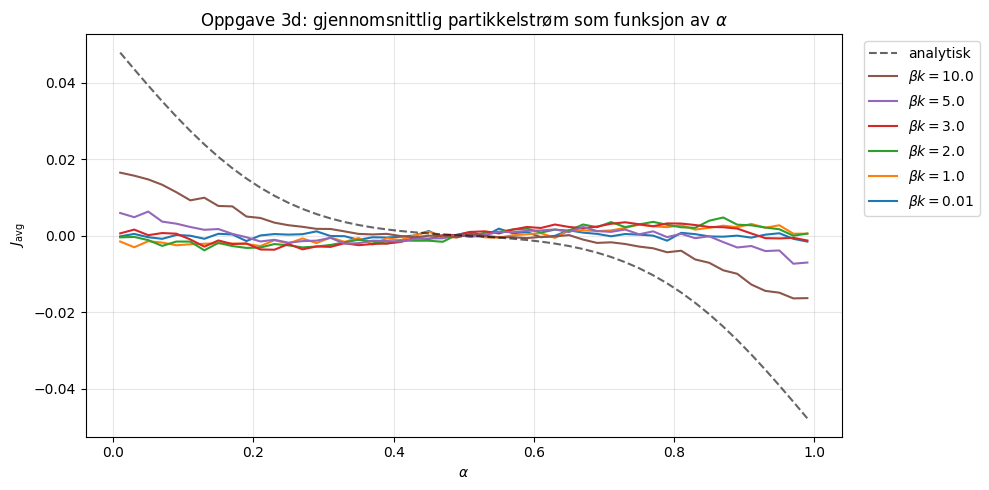

In [26]:
plot_oppgave_3d(params_oppgave_3)

I grafen over ser man hvordan lavere verdier av $\beta k$ ikke samsvarer like godt med den analytiske løsningen. Som man ser gir $\beta k = 10.0$ størst utslag ved lave og store verdier av $\alpha$, mens $\beta k = 0.01$ gir minst. Som vi så i oppgave 3d) var $\beta k = 1000$ tilnærmet ganske lik den analytiske løsningen, som også tyder på at lavere verdier av $\beta k$ fører til grafer som ligger nærmere $J_{\text{avg}}(\alpha) = 0$. Grunnen til dette ligger i at ved lavere verdier av $\beta k$ blir helningen til potensialfunksjonen $V_1$ mindre, som fører til at vi ikke lenger får en dominant $p_{\text{neg}}$ eller $p_{\text{pos}}$. Bevegelsen til partiklene blir dermed mindre deterministisk og når $\beta k \to 0$ nærmer vi oss tilfeldig virrevanding hvor $J_{\text{avg}}(\alpha) = 0$. Dette kan fysisk forstås ved at høy temperatur fører til større termiske fluktuasjoner, slik at partiklene sprer seg mer tilfeldig i rommet ($\beta k \to 0$ er ekvivalent med at $T \to \infty$).

### Oppgave 3e)

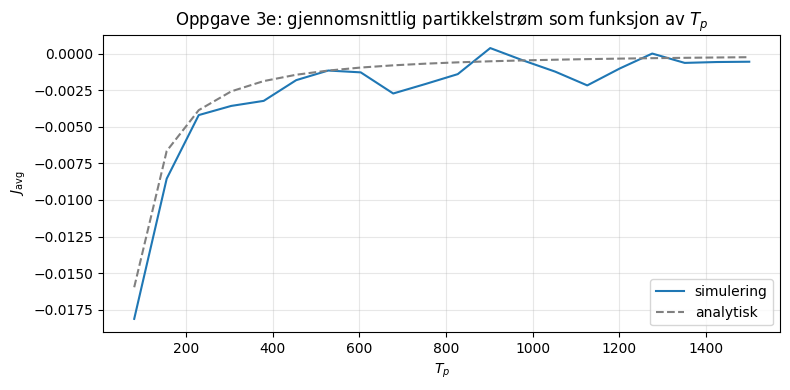

In [27]:
plot_oppgave_3e(params_oppgave_3)

I grafen over ser man hvordan gjennomsnittlig partikkelstrøm endrer seg som funksjon av $T_p$ slik som i oppgave 3b) bare at i denne simuleringen så er bredden $N_x = 10$ mindre. Som man ser er partikkelstrømmen $|J_{\text{avg}}|$ størst ved lave verdier av $T_p$, men blir mindre når $T_p$ øker. Ettersom $N_x$ nå er mindre kan partiklene komme seg lenger unna nullpunktene når $V_2$ potensialet skrur seg på. Som man ser er $|J_{\text{avg}}|$ størst ved lave verdier av $T_p$, og avtar når $T_p$ øker. Siden $N_x$ er mindre, vil partiklene allerede ved relativt små verdier av $T_p$ kunne diffundere en betydelig del under potensialperioden $V_2$. Dermed tilsvarer $T_p = 80$ i dette systemet omtrent mye større verdier av $T_p$ i oppsettet fra oppgave 3b), hvor potensialperioden var $N_x = 100$, altså ti ganger større. Det vil si at grafen vi ser her er allerede forbi sitt $|J_{\text{avg}}|$ maksimumspunkt, og vil bare synke videre. Grunnen til at den simulerte grafen nærmer seg 0 ved enda større verdier av $T_p$ er fordi partiklene lokaliserer seg ved nullpunktene og slutter å flytte på seg etter en viss tid i halvperioden ($(T_p, 2T_p)$), dermed bidrar ikke dette lenger til strømning, men man deler fortsatt på $2T_p$ som er større, som betyr at $|J_{\text{avg}}|$ blir mindre. 

Man kan også observere at den analytiske løsningen ligger ganske nær den simulerte, men at simuleringen ser ut til å gi noe større absoluttverdi for større verdier av $T_p$. En mulig forklaring er at for den analytiske løsningen får man bare et bidrag på $\pm N_x$ eller $0$ basert på om partikkelen beveger seg til neste potensialbrønn, men i simulasjonen her kan en partikkel bidra med mere enn $N_x$ ettersom vi teller alle stegene den tar. Eksempelvis kan en partikkel gå $2N_x$ steg mot venstre under $V_2$ og dermed bidra med den mengden til strømningen. Så den analytiske løsningen undervurderer bidraget av negativ transport, spesielt ved høye $T_p$ verdier hvor partiklene kan flytte seg lenger. Det er derfor den simulerte løsningen ligger lavere og har større absoluttverdi. Det man også her kan legge merke til er at asymmetrien til $V_1$ vil holde også for høyere ordens potensialbrønner. Hvis vi kaller potensialbrønnen vi startet i for $0.$ potensialbrønn vil $1.$ ordens potensialbrønn mot venstre starte i $x = -3$ og $1.$ ordens mot høyre i $x = 8$. $2.$ ordens vil starte til venstre i $x = -13$, og til høyre i $x = 18$ osv. Det man ser her er at brønnene til venstre alltid kommer før brønnene til høyre. Det vil si at det er større sjans for at en partikkel på venstre side havner i nullpunktet i en høyere ordens potensialbrønn enn en partikkel på høyre side, som vil føre til at vi får et større bidrag til negativ strømning, som er det vi også observerer relativt til den analytiske løsningen.

### Oppgave 3f)

Som vi har sett i grafene i oppgave 3e) og 3d) ligger ikke den analytiske løsningen helt sammen med de simulerte løsningene. Det er bare under visse verdier av parametre at de ligger ganske tett opp mot hverandre. Selv om den analytiske løsningen hadde vært enda mer presis ville vi fortsatt forventet litt støy da simuleringen vil inneholde stokastiske variasjoner.

Som man ser i oppgave 3e) vil den analytiske løsningen ikke stemme ganske godt overens med de simulerte løsningene dersom $\beta k$ er for liten. I oppgave 3c) samsvarte de ganske godt, men da var $\beta k = 1000$. Grunnen til dette ligger i at i den analytiske løsningen antar man at partiklene beveger seg deterministisk basert på hvor i potensialfunksjonen $V_1$ de befinner seg. Altså at kun en av $p_{\text{neg}}$, $p_{\text{0}}$ eller $p_{\text{pos}}$ er 1 mens de andre er 0. Dette gjelder ganske godt for veldig store verdier av $\beta k$ ut ifra formelen til sannsynlighetene, men det gjelder ganske dårlig ved lavere verdier av $\beta k$. Da vil nemlig bevegelsen til en partikkel ikke være fullt ut bestemt av hvor den befinner seg i potensialfunksjon. Da vil det være en ikke neglisjerbar sannsynlighet for at de ikke beveger seg nedover potensialfunksjonen. Den fysiske forstålsen av dette er at den analytiske løsningen er gyldig ved veldig lave temperaturer hvor potensialet dominerer over termisk støy.

I 3d) ser man også at den analytiske løsningen ikke passer helt med det vi simulerer. Hovedårsaken til dette ligger i at i utledningen til $J_{\text{avg}}$ så antar man at partikkel som beveger seg forbi den $0.$ potensialbrønnen (der vi starer) kun vil bidra med en mengde $\pm N_x$ på antall steg den tar. Dette er en overforenkling, og blir upresis ved større verdier at $T_p$ som vi så i plottet i 3d). For å ha gjort den analytiske løsningen mer presis skulle man dermed ha hatt en diskret sum av integraler, hvor man integrerer over alle potensialbrønner og vekter dem riktig ut ifra hvor mange $N_x$ de bidrar med. Eksempelvis skulle man for $2.$ ordens potensialbrønn på høyre side integrert fra $[(\alpha + 1)N_x, (\alpha + 2) N_x]$ og ganget med $2N_x$ da det ble bidraget for partikler som havner her når $V_1$ potensialet skrur seg på.

Den analytiske løsningen antar også kontinuerlig diffusjon beskrevet av diffusjonsligningen, som gir en perfekt normalfordelt partikkelfordeling. I simuleringen skjer bevegelsen derimot ved diskrete hopp på et gitter. I tillegg vil et begrenset antall partikler $N_p$	​føre til statistiske fluktuasjoner rundt den analytiske forventningen.

Oppsummert holder altså ikke den analytiske løsningen ved lave verdier av $\beta k$ og ved for høye verdier av $T_p$. I tillegg kan diskretisering av rommet og et begrenset antall partikler føre til mindre avvik mellom simuleringen og den analytiske løsningen.

## Oppgave 4

### Oppgave 4d)

Vi valgte artikkelen *Memory-Induced Transport and Arrest in Flashing Ratchets*. Den handler om hvordan partikler beveger seg i et såkalt *flashing ratchet*-potensial, altså et asymmetrisk potensial som slås av og på over tid. Dette er litt samme type system som vi har jobbet med i oppgavene tidligere i prosjektet.

I figur 1 i artikkelen viser forfatterne noen resultater for hvordan partiklene beveger seg. I figur 1a ser vi partikkelstrømmen $J$ som funksjon av tid. Det man ser er at strømmen øker ganske raskt i starten, og så flater den mer ut etter hvert. Den røde kurven gir tydelig større strøm enn de andre. Det betyr egentlig bare at partiklene i det tilfellet beveger seg mer effektivt gjennom potensialet. Forskerne forklarer dette med at støyen i systemet har to karakteristiske frekvenser, som på en måte hjelper partiklene å “komme seg videre”.

I figur 1b viser de den gjennomsnittlige kvadratiske forskyvningen (MSD). Denne forteller hvor langt partiklene i gjennomsnitt beveger seg fra startpunktet sitt. Her ser man at forskyvningen kan øke raskere enn ved vanlig diffusjon. Det betyr at partiklene sprer seg raskere enn man kanskje skulle tro. Dette kalles superdiffusjon. Årsaken til dette er at støyen i modellen har en slags hukommelse, så bevegelsen til partiklene ikke er helt tilfeldig fra steg til steg.

Modellen de bruker i artikkelen er basert på en Langevin-ligning, hvor partiklene beveger seg i et ratchet-potensial samtidig som de påvirkes av støy og friksjon. Støyen de bruker er ikke helt tilfeldig, men har tidskorrelasjoner, altså at systemet “husker” litt av hva som skjedde tidligere.

I oppgaven vår bruker vi en mye enklere modell. Her lar vi partiklene gjøre en random walk, hvor de hopper ett steg til venstre eller høyre langs en diskret akse. I tillegg har vi hard-core repulsjon, som betyr at to partikler ikke kan være på samme sted. Hvis en partikkel prøver å flytte seg til et sted hvor det allerede er en annen partikkel, så blir bevegelsen stoppet og partikkelen blir stående der den er.

Så hovedforskjellen er egentlig at artikkelen bruker en mer avansert og realistisk modell, mens vi bruker en enklere simulering. Men ideen bak er ganske lik: man prøver å forstå hvordan partikler kan få en netto bevegelse i én retning i et asymmetrisk ratchet-potensial, selv om bevegelsen i utgangspunktet er tilfeldig.

---

### Referanse

Mazzitello, K. I., Zarlenga, D. G., & Arizmendi, C. M. (2025). *Memory-Induced Transport and Arrest in Flashing Ratchets*. arXiv. https://arxiv.org/html/2512.14891v1
 Med bilde.

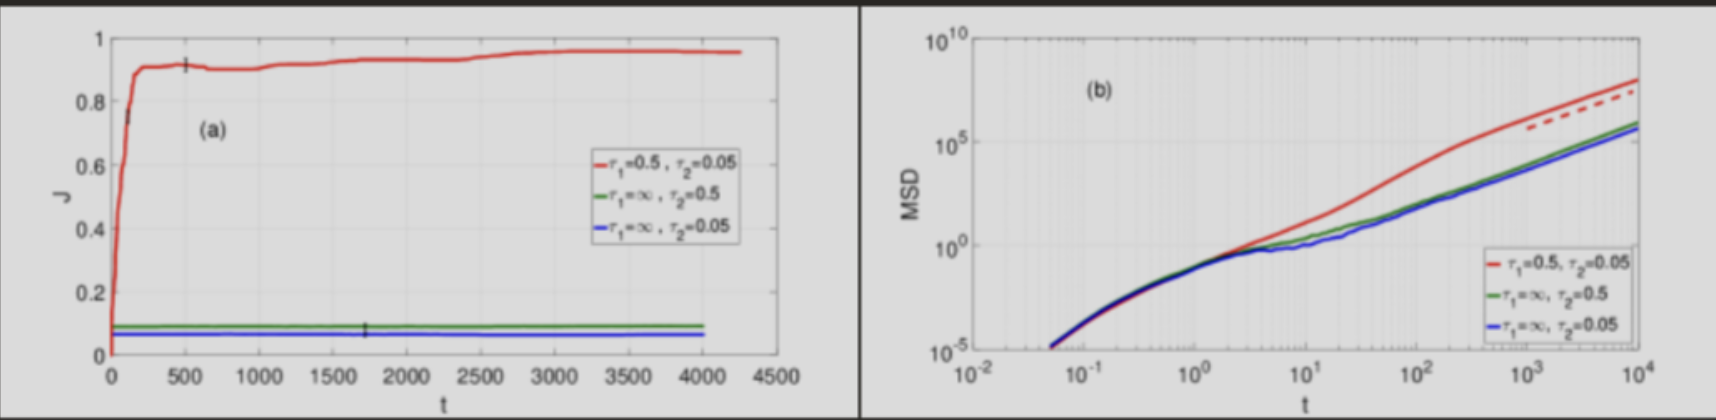

## KI erklæring